# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used


In [1]:
import sys

sys.path.append("../")
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from mlresearch.datasets import BinaryDatasets
from explainerpfn.base import SingleFeatureExplainerPFN, ExplainerPFN

# just a simple toy dataset (all continuous features)

datasets = BinaryDatasets(names=["BANKNOTE AUTHENTICATION"]).download()
df = datasets["BANKNOTE AUTHENTICATION"]

df_train_rf = df.sample(500, replace=False, random_state=42)
df_train = df.drop(df_train_rf.index).sample(500, replace=False, random_state=42)
df_test = df.drop(df_train_rf.index).drop(df_train.index)

# preprocess data (standardscaler)
scaler = StandardScaler().fit(
    df_train_rf.loc[:, df_train_rf.columns.drop("target")].values
)

Xy = []
for df_ in [df_train_rf, df_train, df_test]:
    df_ = df_.reset_index(drop=True)
    df_.loc[:, df_.columns.drop("target")] = scaler.transform(
        df_.loc[:, df_.columns.drop("target")].values
    )
    X = df_.loc[:, df_.columns.drop("target")].values
    y = df_["target"].values
    Xy.append((X, y))

(X_train_rf, y_train_rf), (X_train, _), (X_test, _) = Xy

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

# Get a classifier, predictions and SHAP explanations

In [2]:
clf = MLPClassifier(
    max_iter=2000, alpha=0.05, learning_rate="invscaling", random_state=42
)
clf.fit(X_train_rf, y_train_rf)

y_train = clf.predict_proba(X_train)[:, 1]
y_test = clf.predict_proba(X_test)[:, 1]

In [3]:
def get_shap_values(X, model, masker=None):
    """
    Get SHAP values for the given model and data.
    """
    xai = shap.Explainer(model=model, masker=masker)

    shap_explanation_train = xai(X).values[:, :, -1]

    return shap_explanation_train

In [4]:
all_shap_values = []
for X, y in tqdm(
    list(zip([X_train, X_test], [y_train, y_test])), desc="Calculating SHAP values"
):
    X_shap = get_shap_values(X, clf.predict_proba, masker=X_train)
    df_shap = pd.DataFrame(
        X_shap.astype(float), columns=df_train.columns.drop("target")
    )
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))

(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

# PFN Explanations - Single feature

In [5]:
self = SingleFeatureExplainerPFN(feature_idx=1, random_state=42)
self.fit(X_train, y_train)

# averaged_logits, outputs, borders = self.forward(X, np.zeros_like(y), 0)
output = self.predict(X_test, y_test)

# Generate explanations for the entire dataset

In [6]:
explanations = np.zeros_like(X_test, dtype=float)
for i in tqdm(range(X_test.shape[1])):
    singlepfn = SingleFeatureExplainerPFN(
        feature_idx=i, softmax_temperature=0.9, random_state=42
    )
    singlepfn.fit(X_train, y_train)
    explanations[:, i] = singlepfn.predict(X_test, y_test)

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
# Apply correction to ensure additivity
base_value = np.mean(y_train)
error = y_test - (explanations.sum(axis=1) + base_value)
error = (
    np.repeat(error.reshape(-1, 1), repeats=explanations.shape[1], axis=1)
    / explanations.shape[1]
)
explanations_corrected = explanations + error

In [8]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values"] = df.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(
    explanations.astype(float), columns=df_train.columns.drop("target")
)
df_explanations["target"] = y_test
correlations["pfn_explanations"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_explanations_corrected = pd.DataFrame(
    explanations_corrected.astype(float), columns=df_train.columns.drop("target")
)
df_explanations_corrected["target"] = y_test
correlations["pfn_explanations_corrected"] = df_explanations_corrected.corr()["target"]

# Correlation between PFN explanations and SHAP values
correlations["pfn_explanations_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns,
)

pd.DataFrame(correlations)

,input_values,pfn_explanations,pfn_explanations_corrected,pfn_explanations_shap
0,-0.724843,0.973882,0.598113,0.692759
1,-0.444688,-0.040590,-0.050603,-0.170889
2,0.155883,-0.390217,-0.229449,-0.011395
3,-0.023424,0.154340,0.195145,0.166559
target,1.000000,1.000000,1.000000,1.000000


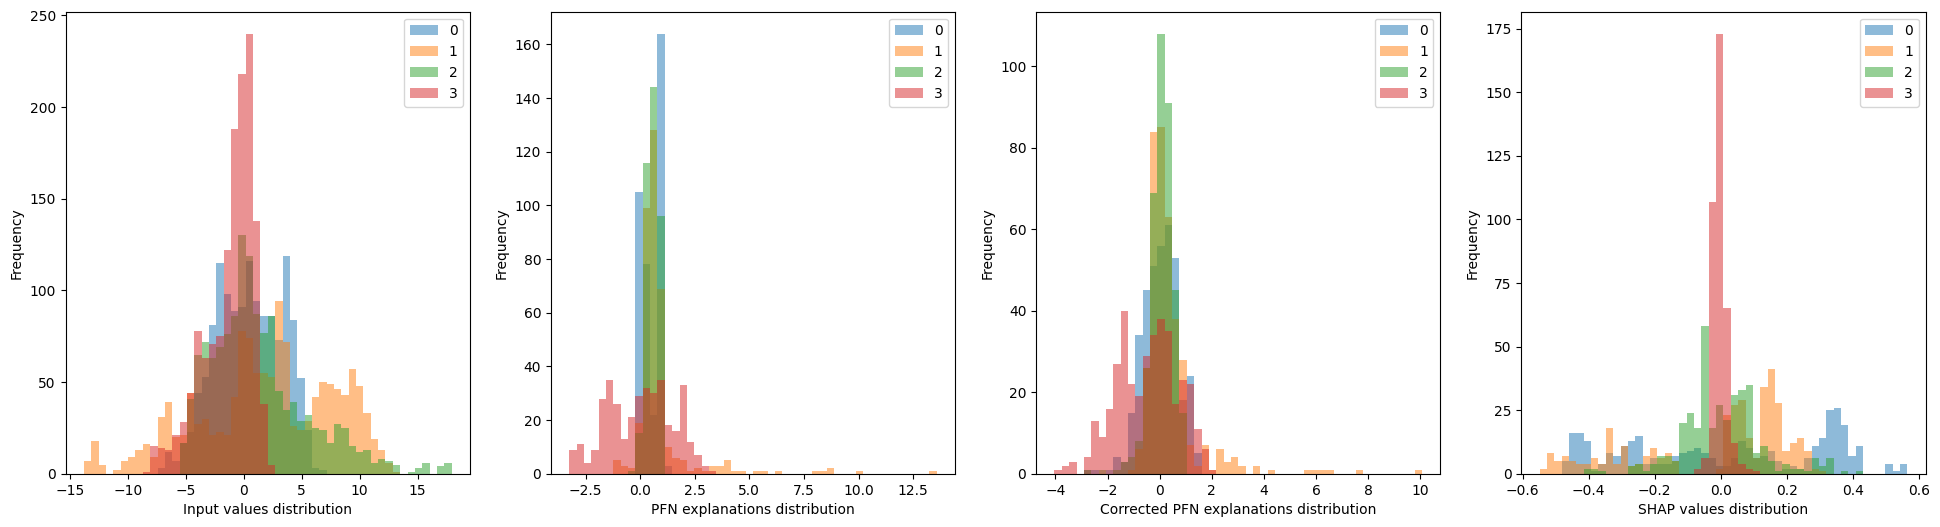

In [9]:
label_data = {
    "Input values": df.drop(columns="target"),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
    "SHAP values": df_shap.drop(columns="target"),
}

fig, axes = plt.subplots(
    nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6)
)
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50,
        alpha=0.5,
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

# Estimating feature importance after model training

In [31]:
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test, y_test)

In [ ]:
# Apply correction to ensure additivity
# eps = (y_test - xai.base_value_) / explanations.sum(axis=1)
# explanations_corrected = explanations * eps.reshape(-1, 1)

# This approach can lead to outliers, so we clip them
# threshold = y_test.std() * 3
# explanations_corrected = np.clip(
#     explanations_corrected, a_min=-threshold, a_max=threshold
# )

In [51]:
(lr.coef_ * df.corr()["target"].drop("target").values * -1)

array([7.08018084, 2.00613574, 0.04890568, 0.23763464])

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression(fit_intercept=False)
lr.fit(explanations, y_test - y_test.mean())
# print(lr.score(X, y))
explanations_corrected = explanations * (lr.coef_ * np.sign(df.corr()["target"].drop("target").values) * -1)  # , lr.intercept_

In [60]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values_vs_target"] = df.corr()["target"]

# Correlation between shapley values and the predicted target
correlations["shap_vs_target"] = df_shap.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(
    explanations.astype(float), columns=df_train.columns.drop("target")
)
df_explanations["target"] = y_test
correlations["pfn_exp_vs_target"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_explanations_corrected = pd.DataFrame(
    explanations_corrected.astype(float), columns=df_train.columns.drop("target")
)
df_explanations_corrected["target"] = y_test
correlations["pfn_exp_corr_vs_target"] = df_explanations_corrected.corr()["target"]

# Correlation between PFN explanations and SHAP values
correlations["pfn_exp_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations.columns
    ],
    index=df_explanations.columns,
)

# Correlation between corrected PFN explanations and SHAP values
correlations["pfn_exp_corr_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1]
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns,
)

pd.DataFrame(correlations)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,-0.724843,0.829661,0.738503,0.738503,0.847647,0.847647
1,-0.444688,0.659072,0.522974,0.522974,0.913468,0.913468
2,0.155883,0.113648,0.240635,0.240635,0.731502,0.731502
3,-0.023424,0.141111,0.652643,0.652643,-0.074838,-0.074838
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


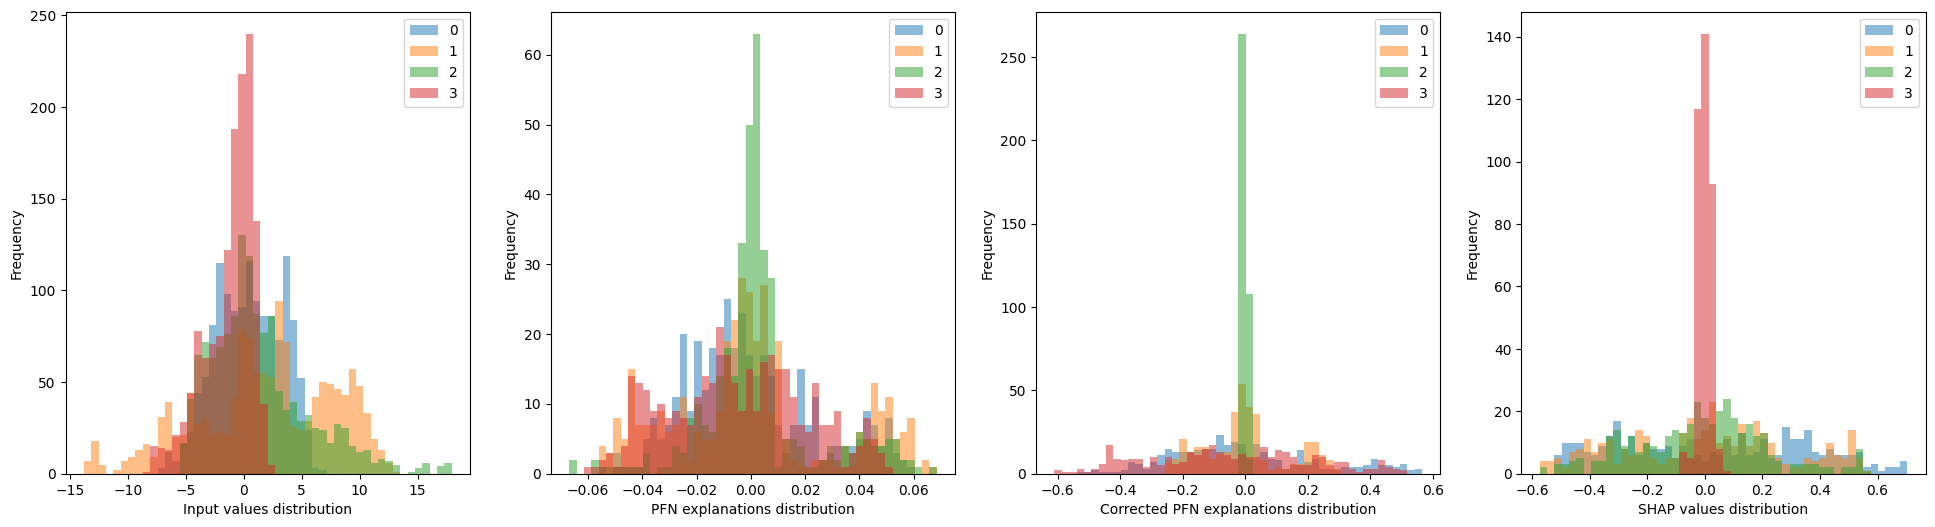

In [61]:
label_data = {
    "Input values": df.drop(columns="target"),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
    "SHAP values": df_shap.drop(columns="target"),
}

fig, axes = plt.subplots(
    nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6)
)
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50,
        alpha=0.5,
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

0.8437752612719764


<Axes: ylabel='Frequency'>

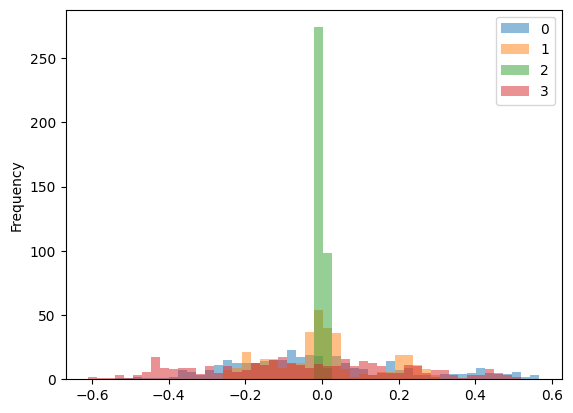

In [30]:
from sklearn.linear_model import LinearRegression


X, y = df_explanations.drop(columns="target"), df_explanations["target"] - df_explanations["target"].mean()
lr = LinearRegression(fit_intercept=False)
lr.fit(X, y)
print(lr.score(X, y))
test = X * lr.coef_  # , lr.intercept_
test.plot.hist(bins=50, alpha=0.5)

np.float64(0.48579014312730723)

In [9]:
label_data["SHAP values"].describe()

,0,1,2,3
count,372.000000,372.000000,372.000000,372.000000
mean,0.023280,-0.002287,-0.019468,-0.001330
std,0.324791,0.286771,0.225438,0.022173
min,-0.516314,-0.573361,-0.567633,-0.079202
25%,-0.274488,-0.228646,-0.181577,-0.017684
50%,0.034916,0.012938,-0.005153,-0.000940
75%,0.298286,0.181553,0.115936,0.014850
max,0.703144,0.552201,0.552187,0.068375


In [10]:
label_data["PFN explanations"].describe()

,0,1,2,3
count,372.000000,372.000000,372.000000,372.000000
mean,-0.000266,0.000093,0.002587,-0.004817
std,0.024088,0.030034,0.020884,0.025382
min,-0.054140,-0.055324,-0.066980,-0.060114
25%,-0.017659,-0.019223,-0.005619,-0.023880
50%,-0.004261,-0.001870,0.001062,-0.005593
75%,0.015406,0.010471,0.006633,0.012849
max,0.057936,0.066522,0.068607,0.051028
